### Libraries

In [ ]:
import numpy as np
import numba as nb
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from joblib import Parallel, delayed
from datetime import datetime
import pandas as pd
import os
import re
from scipy.interpolate import griddata
from scipy.integrate import quad

### path to save the data
path_to_save = 'PLACEHOLDER_FOR_DATA_SAVE_PATH/'
###path to save the plots
path_to_save_pltos = 'PLACEHOLDER_FOR_PLOTS_SAVE_PATH/'

### Utils

In [2]:
#function to simulate the FH model
@nb.njit
def FH(params, N, N_steps, dt, ic = None, Z = None):

    #parameters of the model
    epsilon, psi, delta, nu, alpha, beta, gamma, mu, sigma = params

    #initial conditions
    if ic is None:
        x_0 = np.random.randn(N)
        y_0 = np.random.randn(N)
    else:
        #initial conditions
        x_0, y_0 = ic

    #quenched current
    if Z is None:
        Z = np.random.randn(N)

    #observable initialization
    X = np.zeros(N_steps)  

    #initialization of vectors
    x = np.zeros((N, N_steps))
    y = np.zeros((N, N_steps))

    #random initial conditions
    x[:, 0] = x_0
    y[:, 0] = y_0

    #temporal integration with eulero
    for t in range(1, N_steps):
        for n in nb.prange(N):
            X[t-1] = np.mean(x[:, t-1])   
            x[n, t] = x[n, t-1] + dt*(psi*x[n, t-1] + delta*(x[n, t-1])**3 + nu*y[n, t-1] + mu + sigma*Z[n] +epsilon*X[t-1])
            y[n, t] = y[n, t-1] + dt*alpha*(x[n, t-1] + beta*y[n, t-1]+gamma)
    X[N_steps-1] = np.mean(x[:, N_steps-1])
            
    return x, y, X, Z

#function to estimate the limit cycle of the -FH model
def naive_estimate_limit_cycle(x, y, dr = 0.01):
    #computing the averages
    X = np.mean(x, axis = 0)
    Y = np.mean(y, axis = 0)

    #computing the limit cycle
    limit_cycle = []

    #maximum number of steps
    N_steps = X.shape[0]
    
    for kk in range(2, N_steps):
        if np.sqrt((X[-kk]-X[-1])**2+(Y[-kk]-Y[-1])**2)<dr and kk>100:
            break
        else:
            limit_cycle.append([X[-kk], Y[-kk]])

    limit_cycle = np.array(limit_cycle)

    return  None, limit_cycle[:, 0], limit_cycle[:, 1]



def estimate_limit_cycle(x, y, phase_bins=1000, window_size=5):
    # Step 1: Compute the phase of each oscillator
    theta = np.arctan2(y, x)  # Phase in range [-π, π]
    
    # Step 2: Wrap phases into [0, 2π]
    theta = (theta + 2 * np.pi) % (2 * np.pi)
    
    # Step 3: Define phase grid
    phi_grid = np.linspace(0, 2 * np.pi, phase_bins, endpoint=False)

    # Step 4: Compute mean x and y per phase bin
    mean_x = np.zeros(phase_bins)
    mean_y = np.zeros(phase_bins)

    delta_theta = 2 * np.pi / phase_bins
    for i, phi in enumerate(phi_grid):
        mask = (theta >= phi) & (theta < phi + delta_theta)  # Select oscillators in bin
        if np.any(mask):  # Avoid empty bins
            mean_x[i] = np.mean(x[mask])
            mean_y[i] = np.mean(y[mask])
        else:
            mean_x[i] = np.nan
            mean_y[i] = np.nan

    mean_x = mean_x[mean_x != np.nan]
    mean_y = mean_y[mean_y != np.nan]

    return phi_grid, mean_x, mean_y


#### function to plot the FH model
def plotFH(t, xs, ys, X, Z, params, path_to_save_plots = None):

    x = np.mean(xs, axis = 0)
    y = np.mean(ys, axis = 0)

    fig, ax = plt.subplots(1, 3, figsize=(18, 5))

    #### plot the density plot of the points
    hist = ax[0].hist2d(xs.flatten(), ys.flatten(), bins = 100, density = True, cmap='plasma')
    ax[0].set_xlabel('x')
    ax[0].set_ylabel('y')
    fig.colorbar(hist[3], ax=ax[0], label = 'Density of points')


    ### plot the trajectory of the mean values in the phase space
    sc = ax[1].scatter(x, y, c=t, cmap='plasma', marker = '.')
    fig.colorbar(sc, ax=ax[1], label = 'Time')
    ax[1].set_xlabel('X')
    ax[1].set_ylabel('Y')


    ### plot the time-series of the observable
    n_iters= np.min([10, X.shape[0]])
    for i in range(X.shape[0])[-n_iters:]:
        ax[2].plot(t, X[i, :], label = 'it. %d' % i)
 
    ax[2].set_xlabel('Time')
    ax[2].set_ylabel('X')
    ax[2].legend()

    fig.suptitle(r'FH simulation - $\epsilon=%.2f$' % params[0])

    if path_to_save_plots is not None:
        plt.savefig(path_to_save_plots)
        plt.close()
    else:
        plt.show()


### function to plot the limit cycle and the phase space
def plot_limit_cycle(x, y, lc_x, lc_y, params, path_to_save_plots=None):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    hist = ax.hist2d(x.flatten(), y.flatten(), bins=100, cmap='plasma', density=True)  # Plot density of points
    fig.colorbar(hist[3], ax=ax, label='Density of points')
    ax.plot(lc_x, lc_y, color='aqua', linewidth=2)  # Plot limit cycle
    ax.set_xlim(-2, 2)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('Limit cycle and phase space point density')

    plt.tight_layout
    fig.suptitle(r'FH - Limit cycle - $\epsilon=%.2f$' % params[0])

    if path_to_save_plots is not None:
        plt.savefig(path_to_save_plots)
        plt.close()
    else:
        plt.show()


#function to estimate the baricenter of the -FH model as the center for epsilon = 0
def estimate_baricenterFH(params, N_average = 1000, N = 1000, N_steps = 10_000, dt = 0.01):

    #setting the coupling epsilon to zero
    params = list(params)
    params[0] = 0
    params = tuple(params)
    
    #simulating the model with epsilon = 0
    x, y, X, Z  = FH(params, N, N_steps + N_average, dt)

    #computing the geometric center
    X_c = np.mean(x[:, -N_average:])
    Y_c = np.mean(y[:, -N_average:])

    return X_c, Y_c


### function to estimate the geometric center of a limit cycle
def estimate_geometric_center(x, y):
    """Estimate the geometric center of a closed limit cycle using Green's theorem."""
    x = np.asarray(x)
    y = np.asarray(y)

    # Ensure the cycle is closed
    x = np.append(x, x[0])
    y = np.append(y, y[0])

    # Compute the enclosed area A
    A = 0.5 * np.sum(x[:-1] * y[1:] - x[1:] * y[:-1])

    # Compute centroid using Green's theorem
    Cx = (1 / (6 * A)) * np.sum((x[:-1] + x[1:]) * (x[:-1] * y[1:] - x[1:] * y[:-1]))
    Cy = (1 / (6 * A)) * np.sum((y[:-1] + y[1:]) * (x[:-1] * y[1:] - x[1:] * y[:-1]))

    return [Cx, Cy]


### functions that enter the computation of the instable point
def f(x, params):
    epsilon, psi, delta, nu, alpha, beta, gamma, mu, sigma = params
    return -((psi+epsilon)*x+delta*x**3+mu)/(nu)
def g(x, params):
    epsilon, psi, delta, nu, alpha, beta, gamma, mu, sigma = params
    return -x/beta - gamma/beta

### function to find the intersection between two null-clines
def find_intersections(g, f, a, b, params, max_roots=3, num_points=1000):
    # Define h(x) = g(x, params) - f(x, params)
    def h(x):
        return g(x, params) - f(x, params)

    # Generate x values and evaluate h(x)
    x_vals = np.linspace(a, b, num_points)
    h_vals = h(x_vals)

    # Find sign changes (possible roots)
    sign_changes = np.where(np.sign(h_vals[:-1]) != np.sign(h_vals[1:]))[0]
    roots = []

    for idx in sign_changes[:max_roots]:  # Limit to max_roots
        x_root = brentq(h, x_vals[idx], x_vals[idx + 1])  # Solve h(x) = 0
        y_root = g(x_root, params)  # Compute corresponding y-value
        roots.append((x_root, y_root))

    return roots


### function to plot the limit cycle and the interest points
def plot_interest_points(lc_x, lc_y, baricenter, geometric_center, unstable_points, xs, fs, gs, params, path_to_save_plots = None):

    plt.figure(figsize=(6, 6))
    plt.plot(lc_x, lc_y, label = 'Limit cycle')
    plt.plot(xs, fs, label = r'$y = f(x)$')
    plt.plot(xs, gs, label = r'$y = -\frac{x}{\beta} - \frac{\gamma}{\beta}$')
    plt.scatter([p[0] for p in unstable_points], [p[1] for p in unstable_points], color = 'red', marker= 'x', label = 'Unstable points')
    plt.scatter(baricenter[0], baricenter[1], marker = 'x', label = 'Baricenter')
    plt.scatter(geometric_center[0], geometric_center[1], marker = 'x', label = 'Geometric center')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(r'FH - Limit cycle and interest points - $\epsilon=%.2f$' % params[0])
    plt.legend()
    
    if path_to_save_plots is not None:
        plt.savefig(path_to_save_plots)
        plt.close()
    else:
        plt.show()


### function to compute the limit cycle and the interest points parallelized
def limit_cycle(params, hyperparams, path_to_save_data=None, path_to_save_plots=None):
    
    #unpacking the parameters
    epsilon, *fixed_params = params
    N, N_transient, N_stationarity, dt, theta_bins, window_size, dr_lc = hyperparams

    #computing the  simulation
    x, y, X, Z = FH(params, N, N_transient + N_stationarity, dt)

    #estimating the limit cycle
    if window_size is not None:
        phi_grid, lc_x, lc_y = estimate_limit_cycle(x[:, N_transient:], y[:, N_transient:], theta_bins, window_size)
    elif dr_lc is not None:
        _, lc_x, lc_y = naive_estimate_limit_cycle(x[:, N_transient:], y[:, N_transient:], dr = dr_lc)
    else:
        _, lc_x, lc_y = naive_estimate_limit_cycle(x[:, N_transient:], y[:, N_transient:])
   

    #computing interest points
    baricenter = estimate_baricenterFH(params, N_average=1000, N=N, N_steps=N_stationarity, dt=dt)
    geometric_center = estimate_geometric_center(lc_x, lc_y)
    unstable_points = find_intersections(g, f, -2, 2, params)

    #computing the null-clines
    xs = np.linspace(-2, 2, 1000)
    fs = f(xs, params)
    gs = g(xs, params)
  
    #saving the data
    if path_to_save_data is not None:
        np.savez(path_to_save_data+'limit_cycle_epsilon{}'.format(epsilon), lc_x=lc_x, lc_y=lc_y, baricenter=baricenter, geometric_center=geometric_center, unstable_points=unstable_points, xs=xs, fs=fs, gs=gs)


    #saving the plots
    if path_to_save_plots is not None:
        #saving simulation
        plotFH(np.arange(N_stationarity)*dt, x[:, N_transient:], y[:, N_transient:], X[N_transient:], Z, params, path_to_save_plots+'limit_cycle_simulation_epsilon{}.png'.format(epsilon))
        #saving interest points
        plot_interest_points(lc_x, lc_y, baricenter, geometric_center, unstable_points, xs, fs, gs, params, path_to_save_plots+'limit_cycle_interest_points_epsilon{}.png'.format(epsilon))
        #saving limit cycle 
        plot_limit_cycle(x[:, N_transient:], y[:, N_transient:],lc_x, lc_y, params, path_to_save_plots+'limit_cycle_epsilon{}.png'.format(epsilon))

        
    return [params, hyperparams]


#function that return the return time given the limit cycle and the trajectory
def returning_time(limit_cycle, X, Y, N_steps, tau = 10, dr=0.01):

    #assembling the trajectory
    trajectory = np.array([X, Y]).T

    #computing the array of distances as a function of time
    distances = []
    for t in range(N_steps):
        distances.append(np.min(np.sqrt((trajectory[t, 0]-limit_cycle[:, 0])**2+(trajectory[t, 1]-limit_cycle[:, 1])**2)))
    distances = np.array(distances)

    #at each time returns 1 if the distance from limit cycle is smaller than dr
    track = np.zeros(N_steps)       
    for t in range(N_steps):
        if distances[t]<dr:
            track[t] = 1

    #counts the number of consecutive positive tracks, if > tau returns the time
    counter = 0
    for idx, tr in enumerate(track):
        if tr == 1:
            counter = counter + 1
            if counter == tau:
                break
        else:
            counter = 0
            
    return idx, distances, track

#function to compute the retuning time as first intersection with the limit cycle
def returning_time_first_intersection(limit_cycle, X, Y, N_steps, dr=0.01):
    
    #assembling the trajectory
    trajectory = np.array([X, Y]).T

    #computing the array of distances as a function of time
    for t in range(N_steps):
        d = np.min(np.sqrt((trajectory[t, 0]-limit_cycle[:, 0])**2+(trajectory[t, 1]-limit_cycle[:, 1])**2))
        if d<dr:
            break
        
    return t



#### Code to run all the simulations
def FH_control(input, path_to_save):
    ### unpack inputs
    params = input[0]
    N, N_transient, N_stationarity, dt, dr_lc, N_average, N_return, N_times = input[1]
    x0, y0, n = input[2]

    ### running a long  simulation
    x, y, X, Z = FH(params, N, N_transient + N_stationarity, dt)

    ### estimating the limit cycle
    _, lc_x, lc_y = naive_estimate_limit_cycle(x[:, N_transient:], y[:, N_transient:], dr = dr_lc)

    ### estimating the baricenter
    baricenter = estimate_baricenterFH(params, N_average=N_average, N=N, N_steps=N_transient, dt=dt)

    ### estimating the geometric center
    geometric_center = estimate_geometric_center(lc_x, lc_y)

    ### estimating the unstable points
    unstable_points = find_intersections(g, f, -2, 2, params)

    ### computing the null-clines
    xs = np.linspace(-2, 2, 1000)
    fs = f(xs, params)
    gs = g(xs, params)


    #vector to save the return times
    taus = []
    Xs_return = []
    Ys_return = []  

    ### running the controll simulation
    for kk in range(N_times):
        ### sampling a random configuration
        n_conf = np.random.randint(0, N_stationarity)

        #### choosing the i.c. as a translation
        ic = [x[:, N_transient+n_conf]-np.mean(x[:, N_transient+n_conf])+x0+np.random.randn(x[:, N_transient+n_conf].shape[0])*0.1, 
              y[:, N_transient+n_conf]-np.mean(y[:, N_transient+n_conf])+y0+np.random.randn(y[:, N_transient+n_conf].shape[0])*0.1]

        ### running controll simulation
        x_ret, y_ret, X_ret, Z_ret = FH(params, N, N_return, dt, ic = ic, Z = Z)

        #computing the return time
        #return_time, distances, track = returning_time(np.array([lc_x, lc_y]).T, np.mean(x_ret, axis = 0), np.mean(y_ret, axis = 0), N_return, tau = 10, dr = dr_lc)
        return_time = returning_time_first_intersection(np.array([lc_x, lc_y]).T, np.mean(x_ret, axis = 0), np.mean(y_ret, axis = 0), N_return, dr = dr_lc)

        taus.append(return_time)
        Xs_return.append(np.mean(x_ret, axis = 0))
        Ys_return.append(np.mean(y_ret, axis = 0))

    taus = np.array(taus)
    Xs_return = np.array(Xs_return)
    Ys_return = np.array(Ys_return)

    #saving the results    
    np.savez(path_to_save+'data_epsilon{}_icx{}_icy{}_n{}'.format(params[0], x0, y0, n), 
             X = np.mean(x, axis = 0), Y = np.mean(y, axis = 0), 
             lc_x = lc_x, lc_y = lc_y, 
             baricenter = baricenter, geometric_center = geometric_center, unstable_points = unstable_points, 
             xs = xs, fs = fs, gs = gs, 
             taus = taus, Xs_return = Xs_return, Ys_return = Ys_return)
    

    return [params, [N, N_transient, N_stationarity, dt, dr_lc, N_average, N_return, N_times], taus, lc_x, lc_y, baricenter, geometric_center, unstable_points, xs, fs, gs]

## Running the simulations and saving the data

In [3]:
### FIXED PARAMETERS
psi = 1
delta = -1/3
nu = -1
alpha = 0.1
beta = -0.8
gamma = 0.7
mu = 0.6
sigma = 0.1


### COUPLING PARAMETER
epsilon_list = [0.1, 0.2, 0.3, 0.4, 0.5]

### CONTROLL
xs = np.linspace(-2.5, 2.5, 51 )
ys = np.linspace(-0.8, 2, 29)

### HYPERPARAMETERS
N = 1000
N_transient = 8000#40_000
N_stationarity = 2000#10_000
N_average = 2000#10_000
N_return =2000#10_000
dt = 0.05#0.01
dr_lc = 0.03


#### STATISTIC
N_trials = 1
N_times = 100

inputs = []
for epsilon in epsilon_list:
    for x0 in xs:
        for y0 in ys:
            for n in range(N_trials):
                inputs.append(((epsilon, psi, delta, nu, alpha, beta, gamma, mu, sigma), [N, N_transient, N_stationarity, dt, dr_lc,  N_average, N_return, N_times], [x0, y0, n]))


#### Running the parallelized simulations
print('Number of simulations: %d' % len(inputs))

Number of simulations: 7395


## Analysis of the simulations

In [4]:
def simulation_analysis(file, path_to_control_plots=None):

    ### loading the data
    data = np.load(path_to_data + file)

    ### inferring the parameters from the file name
    pattern_epsilon = re.compile('epsilon(.*?)_')
    epsilon = float(pattern_epsilon.findall(file)[0])

    pattern_icx = re.compile('icx(.*?)_')
    icx = float(pattern_icx.findall(file)[0])

    pattern_icy = re.compile('icy(.*?)_')
    icy = float(pattern_icy.findall(file)[0])

    pattern_n = re.compile('_n(.*?).npz')
    n = int(pattern_n.findall(file)[0])
    
    ### unpacking the data
    X = data['X']
    Y = data['Y']
    lc_x = data['lc_x']
    lc_y = data['lc_y']
    baricenter = data['baricenter']
    geometric_center = data['geometric_center']
    unstable_points = data['unstable_points']
    xs = data['xs']
    fs = data['fs']
    gs = data['gs']
    taus = data['taus']
    Xs_return = data['Xs_return']
    Ys_return = data['Ys_return']

    ### producing some plots to controll the simulations
    if path_to_control_plots is not None:
        plot_simulation(epsilon, icx, icy,n,  t, X, Y, lc_x, lc_y, xs, fs, gs, baricenter, geometric_center, unstable_points, Xs_return, Ys_return, taus, path_to_save_plots = path_to_control_plots + file[:-4] + '.png')

    ### analyzing the return times
    taus = np.array(taus)[taus*dt < tau_max]*dt
    mean_tau = np.mean(taus)
    std_tau = np.std(taus)

    ### adding to the df
    return [epsilon, icx, icy, n, mean_tau, std_tau, lc_x, lc_y, baricenter, geometric_center, unstable_points, xs, fs,gs, Xs_return, Ys_return, taus]

In [ ]:
#path to data
path_to_data = 'placeholder_for_data_path/'
path_to_results = 'placeholder_for_results_path/'

#parameters of simulations
dt = 0.05
tau_max = 99

#listing the files
files = os.listdir(path_to_data)
print('Number of files:', len(files))

Number of files: 7395


In [6]:
print('Number of files:', len(files))

results = Parallel(n_jobs=-1, verbose = 11)(delayed(simulation_analysis)(file) for file in files)

df = pd.DataFrame(data = results, columns = ['epsilon', 'icx', 'icy', 'n', 'mean_tau', 'std_tau', 'lc_x', 'lc_y', 'baricenter', 'geometric_center', 'unstable_points', 'xs', 'fs', 'gs', 'Xs_return', 'Ys_return', 'taus'])

#df.to_csv(path_to_results + 'results.csv', index = False)

Number of files: 7395


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done  15 tasks      | elapsed:   

In [7]:
#Loading the final df
#df = pd.read_csv(path_to_results + 'results.csv')

print('DF length:', len(df))
df_cleaned = df[df['mean_tau'] < tau_max]
df_cleaned = df_cleaned.dropna(subset = ['mean_tau'])
print('DF length after cleaning:', len(df_cleaned))
df_cleaned.head()

DF length: 7395
DF length after cleaning: 7395


,epsilon,icx,icy,n,mean_tau,std_tau,lc_x,lc_y,baricenter,geometric_center,unstable_points,xs,fs,gs,Xs_return,Ys_return,taus
0,0.5,1.0,1.7,0,8.4560,0.982300,"[2.1283882959192555, 2.1322095042219913, 2.136...","[0.651589523893113, 0.6399884300923717, 0.6283...","[-0.26319154170743264, 0.5591434826079483]","[-0.08655689224181486, 0.7280804475371838]","[[-1.1991589507240739, -0.6239486884050923]]","[-2.0, -1.995995995995996, -1.991991991991992,...","[0.2666666666666665, 0.2566886993553229, 0.246...","[-1.625, -1.619994994994995, -1.61498998998999...","[[1.000000000000002, 1.003185999097748, 1.0063...","[[1.7000000000000013, 1.701699999999999, 1.703...","[7.5, 9.35, 9.450000000000001, 9.4500000000000..."
1,0.3,0.9,0.3,0,1.6770,0.091493,"[-1.9972739493305467, -2.000595736157488, -2.0...","[0.587712723868618, 0.5966021109933788, 0.6055...","[-0.2631254117359624, 0.5532109406587377]","[-0.08774355890329306, 0.7042704877460431]","[[-0.9911457905501513, -0.36393223818768916]]","[-2.0, -1.995995995995996, -1.991991991991992,...","[0.6666666666666664, 0.6558878985545221, 0.645...","[-1.625, -1.619994994994995, -1.61498998998999...","[[0.9000000000000014, 0.9610565501649991, 1.02...","[[0.3, 0.3067999999999999, 0.313878082750825, ...","[1.6500000000000001, 1.6500000000000001, 1.700..."
2,0.3,1.0,-0.6,0,2.7010,0.007000,"[-1.8433287691092919, -1.8465309283124882, -1....","[0.2303729424276519, 0.23705381231848857, 0.24...","[-0.26883209196863905, 0.5507974804733198]","[-0.08451272391597466, 0.7086048382061736]","[[-0.9911457905501513, -0.36393223818768916]]","[-2.0, -1.995995995995996, -1.991991991991992,...","[0.6666666666666664, 0.6558878985545221, 0.645...","[-1.625, -1.619994994994995, -1.61498998998999...","[[0.9999999999999992, 1.100124950887368, 1.201...","[[-0.5999999999999999, -0.5891000000000002, -0...","[2.7, 2.7, 2.7, 2.7, 2.7, 2.7, 2.7, 2.7, 2.7, ..."
3,0.3,0.8,-0.5,0,2.4805,0.025392,"[-1.8885838719981325, -1.891820494977002, -1.8...","[0.32730599371506686, 0.33460351023087576, 0.3...","[-0.2681071961521985, 0.5472664298551008]","[-0.08533328613396537, 0.7082342895952594]","[[-0.9911457905501513, -0.36393223818768916]]","[-2.0, -1.995995995995996, -1.991991991991992,...","[0.6666666666666664, 0.6558878985545221, 0.645...","[-1.625, -1.619994994994995, -1.61498998998999...","[[0.7999999999999998, 0.897737343578751, 0.997...","[[-0.4999999999999998, -0.4904999999999998, -0...","[2.5, 2.5, 2.45, 2.45, 2.5, 2.5, 2.45, 2.45, 2..."
4,0.3,-1.3,-0.6,0,6.1890,0.248654,"[-1.8963771864359829, -1.8996197171911042, -1....","[0.3446569244296347, 0.35206327612007077, 0.35...","[-0.26622468740725774, 0.5522361313230407]","[-0.08516886298377675, 0.7078318510349791]","[[-0.9911457905501513, -0.36393223818768916]]","[-2.0, -1.995995995995996, -1.991991991991992,...","[0.6666666666666664, 0.6558878985545221, 0.645...","[-1.625, -1.619994994994995, -1.61498998998999...","[[-1.2999999999999987, -1.2870822535070452, -1...","[[-0.6, -0.6006000000000004, -0.60113301126753...","[6.2, 5.550000000000001, 6.25, 6.3000000000000..."


#### Heatmaps

In [8]:
#set plot size
plt.rcParams["figure.autolayout"] = True

plt.rcParams['font.size'] = 10   # Default font size for text
plt.rcParams['axes.titlesize'] = 10   # Font size for axes titles
plt.rcParams['axes.labelsize'] = 11 # Font size for x and y labels
plt.rcParams['xtick.labelsize'] = 9 # Font size for x tick labels
plt.rcParams['ytick.labelsize'] = 9 # Font size for y tick labels


#set-up the font as in latex
plt.rcParams.update({
    "font.size": 10,
    "font.family": "serif",
    "font.serif": "cmr10",
    "mathtext.fontset": "cm",
    "axes.formatter.use_mathtext": True
})

#available styles
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [9]:
#! pip install palettable
import palettable.scientific.sequential as dmftaffa

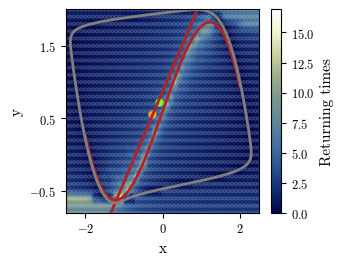

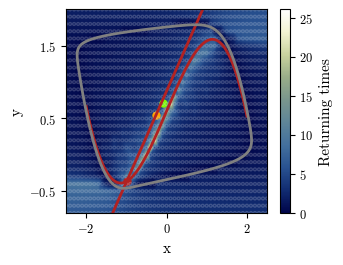

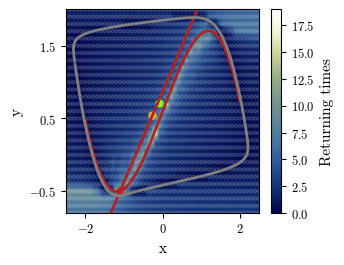

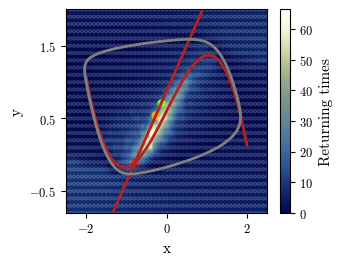

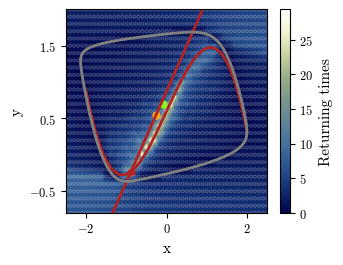

In [10]:
epsilon_list = df['epsilon'].unique()

for epsilon in epsilon_list:

    df_eps = df_cleaned[df_cleaned['epsilon'] == epsilon]

    n = np.random.randint(0, len(df_eps))

    lc_x = df_eps.iloc[n]['lc_x']
    lc_y = df_eps.iloc[n]['lc_y']

    baricenter = df_eps.iloc[n]['baricenter']
    geometric_center = df_eps.iloc[n]['geometric_center']
    unstable_points = df_eps.iloc[n]['unstable_points']

    icx = df_eps.iloc[n]['icx']
    icy = df_eps.iloc[n]['icy']

    x_f = df_eps.iloc[n]['xs']
    fs = df_eps.iloc[n]['fs']
    gs = df_eps.iloc[n]['gs']


    x_low = -2.5
    x_high = 2.5
    y_low = -0.8
    y_high = 2

    query_x = np.linspace(x_low, x_high, 400)
    query_y = np.linspace(y_low, y_high, 400)

    query_grid = np.meshgrid(query_x, query_y)

    xs = df_eps['icx']
    ys = df_eps['icy']
    values = df_eps['mean_tau']
    
    grid_values = griddata((xs, ys), values, (query_grid[0], query_grid[1]), method='linear')


    plt.figure(figsize=(8.9/2.54, 7/2.54))
    sc = plt.imshow(grid_values, extent=(x_low, x_high, y_low, y_high), origin='lower', cmap=dmftaffa.Davos_10.mpl_colormap, aspect='auto')

# Scatter points with improved colors
    plt.scatter(baricenter[0], baricenter[1], marker='.', color='orange', s=100, label=r'$\epsilon = 0$ center')  # Brighter cyan
    plt.scatter(geometric_center[0], geometric_center[1], marker='.', color='lawngreen', s=100, label=r'geometric center')  # Rich golden yellow
    plt.scatter([p[0] for p in unstable_points], [p[1] for p in unstable_points], color='firebrick', marker='.', s=100, label='Unstable point')  # Stronger red

    # Nullclines with more distinct colors
    plt.plot(x_f, gs, color='firebrick', linewidth=2, alpha=1, label=r'Nullcline $\frac{dy}{dt}=0$')  # Deep magenta
    plt.plot(x_f, fs, color='firebrick', linewidth=2, alpha=1, label=r'Nullcline $\frac{dx}{dt} = 0$')  # Rich orange

    # Colorbar
    plt.colorbar(sc, label='Returning times')

    # Scatter original points with improved edge contrast
    plt.scatter(xs, ys, c=values, s = 4, edgecolors='white', alpha=0.2, cmap=dmftaffa.Davos_10.mpl_colormap)  # Increased alpha for more visibility

    # Limit cycle with refined color
    plt.plot(lc_x, lc_y, color='grey', linewidth=2, label='Limit cycle')  # Softer but distinct teal

    # Labels and title
    plt.xlabel('x')
    plt.ylabel('y')
    plt.xticks([-2, 0, 2])
    plt.yticks([-0.5, 0.5, 1.5])
    plt.xlim(-2.5, 2.5)
    plt.ylim(-0.8, 2)
    #plt.title(r'Interpolated Heatmap $\epsilon$={}'.format(epsilon))
    #plt.legend(loc='lower right')

    plt.tight_layout()
    #plt.savefig(path_to_results + 'heatmap_grid_epsilon{}.pdf'.format(epsilon), bbox_inches='tight', pad_inches=0.1, dpi=300)

   

### Estimating return times

In [11]:
import numpy as np

eps = 0.3
x0 = 0
y0 = 0.5

df_slice = df_cleaned[
    np.isclose(df_cleaned['epsilon'], eps) &
    np.isclose(df_cleaned['icx'], x0) &
    np.isclose(df_cleaned['icy'], y0)
]

df_slice

,epsilon,icx,icy,n,mean_tau,std_tau,lc_x,lc_y,baricenter,geometric_center,unstable_points,xs,fs,gs,Xs_return,Ys_return,taus
3758,0.3,0.0,0.5,0,12.068,8.029908,"[-1.9138465614240794, -1.9171023678688353, -1....","[0.38416226603421005, 0.3918150380256558, 0.39...","[-0.2662636198813263, 0.5520999925771192]","[-0.08546200752128424, 0.7074806158701968]","[[-0.9911457905501513, -0.36393223818768916]]","[-2.0, -1.995995995995996, -1.991991991991992,...","[0.6666666666666664, 0.6558878985545221, 0.645...","[-1.625, -1.619994994994995, -1.61498998998999...","[[4.3853809472693685e-17, 0.005015577942703885...","[[0.5, 0.5014999999999998, 0.5030190778897139,...","[5.7, 4.4, 4.5, 21.1, 4.3, 4.25, 4.3, 13.35000..."


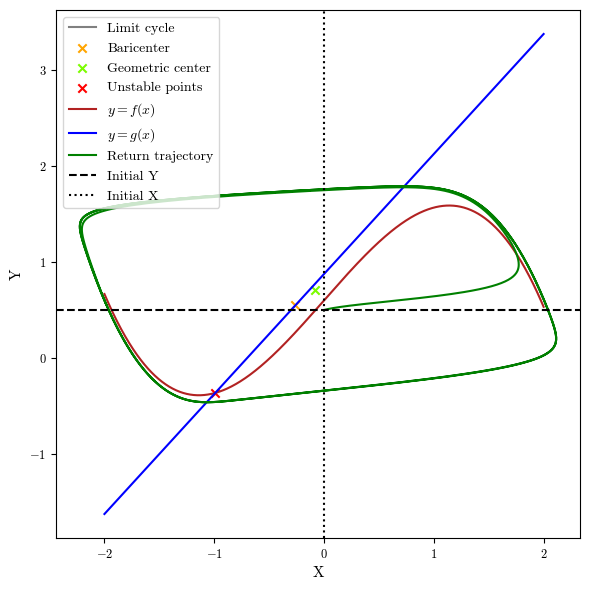

In [12]:
lc_x = df_slice.iloc[0]['lc_x']
lc_y = df_slice.iloc[0]['lc_y']
baricenter = df_slice.iloc[0]['baricenter']
geometric_center = df_slice.iloc[0]['geometric_center']
unstable_points = df_slice.iloc[0]['unstable_points']
taus = df_slice.iloc[0]['taus']
Xs_return = df_slice.iloc[0]['Xs_return']
Ys_return = df_slice.iloc[0]['Ys_return']
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))
plt.plot(lc_x, lc_y, label='Limit cycle', color='grey')
plt.scatter(baricenter[0], baricenter[1], marker='x', label
='Baricenter', color='orange')
plt.scatter(geometric_center[0], geometric_center[1], marker='x', label
='Geometric center', color='lawngreen')
plt.scatter([p[0] for p in unstable_points], [p[1] for
    p in unstable_points], color='red', marker='x', label='Unstable points')
plt.plot(df_slice.iloc[0]['xs'], df_slice.iloc[0]['fs'], label=r'$y = f(x)$', color='firebrick')
plt.plot(df_slice.iloc[0]['xs'], df_slice.iloc[0]['gs'], label=r'$y = g(x)$', color='blue')

plt.plot(Xs_return[0, :], Ys_return[0, :], color='green', linestyle='-', label='Return trajectory')


plt.axhline(y=y0, color='black', linestyle='--', label='Initial Y')
plt.axvline(x=x0, color='black', linestyle=':', label='Initial X')

plt.xlabel('X')
plt.ylabel('Y')
#plt.title(r'FH - Limit cycle and interest points - $\epsilon=%.2f$ % eps)' % eps)
plt.legend()


In [13]:
### FIXED PARAMETERS
psi = 1
delta = -1/3
nu = -1
alpha = 0.1
beta = -0.8
gamma = 0.7
mu = 0.6
sigma = 0.1

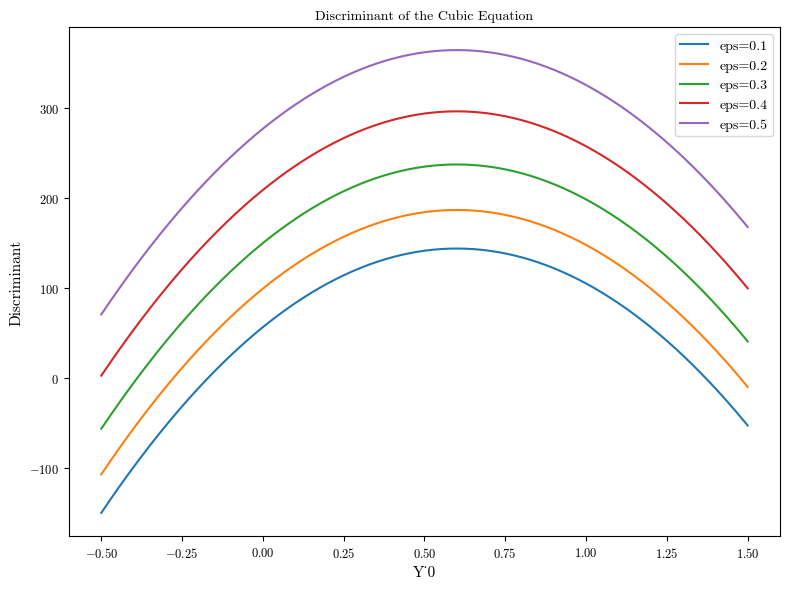

In [14]:
xi = 1
eps_list = [0.1, 0.2, 0.3, 0.4, 0.5]
nu = -1
mu = 0.6
delta = -1/3

plt.figure(figsize=(8,6))

for eps in eps_list:
    Y_0 = np.linspace(-0.5, 1.5, 400)

    a = (xi +eps)
    b = nu*Y_0 + mu

    p = a/delta
    q = b/delta

    disc = -4*p**3 - 27*q**2

    plt.plot(Y_0, disc, label=f'eps={eps}')

plt.legend()
plt.xlabel('Y_0')
plt.ylabel('Discriminant')
plt.title('Discriminant of the Cubic Equation')
plt.legend()

In [15]:
xi = 1
eps=0.3
nu = -1
mu = 0.6
delta = -1/3
Y_0 = y0
X_0 = x0
X_f = -2

a = (xi +eps)
b = nu*Y_0 + mu

p = a/delta
q = b/delta

disc = -4*p**3 - 27*q**2

print('Discriminant:', disc)

Discriminant: 234.84600000000006


In [16]:
# Correct, robust solver for x^3 + p*x + q = 0 with demonstration for p=3.9, q=2.4
import cmath, math

def cbrt(z, tol=1e-14):
    """Real cube root for (near-)real inputs, complex cube root otherwise.
    Returns the real cube root when z is (almost) real to avoid principal-branch issues.
    """
    if abs(z.imag) < tol:
        # real cube root that preserves sign
        return math.copysign(abs(z.real) ** (1/3), z.real)
    else:
        return cmath.exp(cmath.log(z) / 3)

def cubic_roots(p, q, tol=1e-14):
    """
    Solve x^3 + p*x + q = 0 and return three roots (may be real or complex).
    Uses:
      - trig (Casus irreducibilis) when discriminant < 0 (three real roots),
      - Cardano's formula (complex arithmetic) when discriminant > 0,
      - special handling when discriminant == 0 (multiple roots).
    """
    Δ = (q/2)**2 + (p/3)**3

    # Three distinct real roots (casus irreducibilis): use trig formula
    if Δ < -tol:
        rho = math.sqrt(- (p/3))
        # safe argument for acos
        arg = (-q/2) / math.sqrt(-(p/3)**3)
        # Clamp arg to [-1,1] to avoid numerical domain errors
        arg = max(-1.0, min(1.0, arg))
        phi = math.acos(arg)
        x0 = 2 * rho * math.cos(phi/3)
        x1 = 2 * rho * math.cos((phi/3) + 2*math.pi/3)
        x2 = 2 * rho * math.cos((phi/3) + 4*math.pi/3)
        return (x0, x1, x2)

    # Double or triple root (Δ approximately zero)
    if abs(Δ) <= tol:
        u = cbrt(-q/2)
        # double root: x1 = 2u, x2 = x3 = -u
        x1 = 2*u
        x2 = -u
        x3 = -u
        return (x1, x2, x3)

    # Δ > 0: one real root and two complex conjugates. Use Cardano with robust cube roots.
    sqrtΔ = cmath.sqrt(Δ)
    A = -q/2 + sqrtΔ
    B = -q/2 - sqrtΔ
    u = cbrt(A)
    v = cbrt(B)
    x1 = u + v
    # primitive cubic roots of unity: ω = -1/2 + i*sqrt(3)/2
    omega = complex(-0.5, math.sqrt(3)/2)
    omega2 = complex(-0.5, -math.sqrt(3)/2)
    x2 = u*omega + v*omega2
    x3 = u*omega2 + v*omega
    return (x1, x2, x3)

# Demonstration with p=3.9, q=2.4
roots = cubic_roots(p, q)
print("p =", p, "q =", q)
print("Discriminant Δ =", (q/2)**2 + (p/3)**3)
for i, r in enumerate(roots, start=1):
    # show near-real roots as floats for readability
    if abs(r.imag) < 1e-12:
        print(f"Root {i}: {r.real:.12g}  (real)")
    else:
        print(f"Root {i}: {r}")

# Return roots as a Python tuple for interactive use
roots

p = -3.9000000000000004 q = -0.29999999999999993
Discriminant Δ = -2.1745
Root 1: 2.01223457527  (real)
Root 2: -1.93519425461  (real)
Root 3: -0.0770403206562  (real)


(2.01223457526884, -1.9351942546126533, -0.07704032065618768)

In [42]:
tau = 0
for root in roots:
    Ak = 1/(3*delta*root**2 + (xi + eps))
    tau = tau+ Ak*np.log(np.abs((X_f-root)/(X_0-root)))

print('Return time tau:', tau)

Return time tau: 3.6243639305166564


In [17]:
df_epsilon = df_cleaned[df_cleaned['epsilon'] == eps]

results = []
for index, df_slice in df_epsilon.iterrows():
    lc_x = df_slice['lc_x']
    lc_y = df_slice['lc_y']
    baricenter = df_slice['baricenter']
    geometric_center = df_slice['geometric_center']
    unstable_points = df_slice['unstable_points']
    taus = df_slice['taus']
    Xs_return = df_slice['Xs_return']
    Ys_return = df_slice['Ys_return']

    icx = df_slice['icx']
    icy = df_slice['icy']

    xs = df_slice['xs']
    fs = df_slice['fs']
    gs = df_slice['gs']

    x_f1 = 2
    x_f2 = -2

    x0 = icx
    y0 = icy

    a = (xi +eps)
    b = nu*y0 + mu

    p = a/delta
    q = b/delta
    roots = cubic_roots(p, q)
    tau2 = 0
    for root in roots:
        Ak = 1/(3*delta*root**2 + (xi + eps))
        tau2 = tau2 + Ak*np.log(np.abs((x_f2-root)/(x0-root)))

    tau1 = 0
    for root in roots:
        Ak = 1/(3*delta*root**2 + (xi + eps))
        tau1 = tau1 + Ak*np.log(np.abs((x_f1-root)/(x0-root)))

    results.append([x0, y0, tau1, tau2, xs, fs, gs, lc_x, lc_y, baricenter, geometric_center, unstable_points, taus, Xs_return, Ys_return])
    

In [18]:
df_results = pd.DataFrame(data = results, columns = ['icx', 'icy', 'tau1', 'tau2', 'xs', 'fs', 'gs', 'lc_x', 'lc_y', 'baricenter', 'geometric_center', 'unstable_points', 'taus', 'Xs_return', 'Ys_return'])

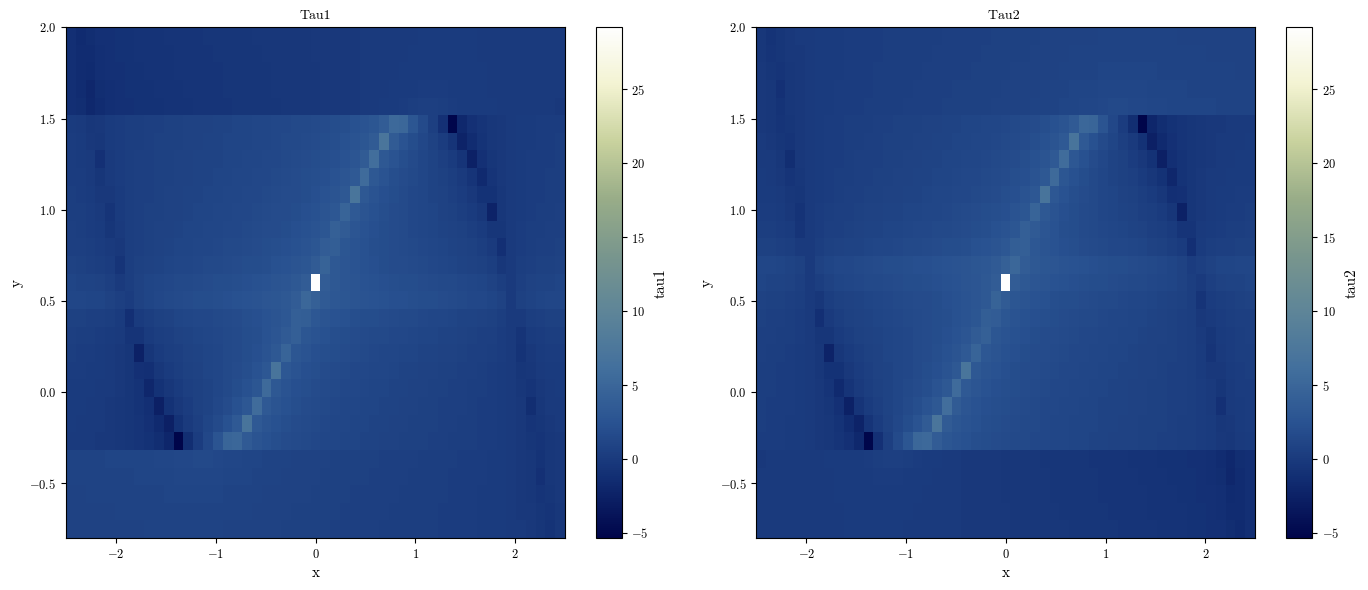

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Assuming df_results already exists
# df_results = pd.DataFrame(data=results, columns=[...])

# Pivot 2D fields for heatmaps
pivot_tau1 = df_results.pivot(index='icy', columns='icx', values='tau1')
pivot_tau2 = df_results.pivot(index='icy', columns='icx', values='tau2')

x = pivot_tau1.columns.values
y = pivot_tau1.index.values

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: tau1 background + (xs, fs) overlay
im1 = axes[0].imshow(np.real(pivot_tau1.values),
                     extent=[x.min(), x.max(), y.min(), y.max()],
                     origin='lower', aspect='auto', cmap=dmftaffa.Davos_10.mpl_colormap)
axes[0].set_title('Tau1')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
fig.colorbar(im1, ax=axes[0], label='tau1')

# --- Plot 2: tau2 background + (xs, fs) overlay
im2 = axes[1].imshow(np.real(pivot_tau2.values),
                     extent=[x.min(), x.max(), y.min(), y.max()],
                     origin='lower', aspect='auto', cmap=dmftaffa.Davos_10.mpl_colormap)
axes[1].set_title('Tau2 ')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
fig.colorbar(im2, ax=axes[1], label='tau2')

# --- Overlay (xs, fs) trajectories
for _, row in df_results.iterrows():
    xs = np.array(row['xs'], dtype=float)
    fs = np.array(row['fs'], dtype=float)
    '''
    # Only plot if both are valid 1D arrays of same length
    if xs is not None and fs is not None and len(xs) == len(fs):
        axes[0].plot(xs, fs, color='white', lw=0.5, alpha=0.6)
        axes[1].plot(xs, fs, color='white', lw=0.5, alpha=0.6)
    '''

plt.tight_layout()
plt.show()


### Final Panel

In [20]:
#set plot size
plt.rcParams["figure.autolayout"] = True

plt.rcParams['font.size'] = 10   # Default font size for text
plt.rcParams['axes.titlesize'] = 10   # Font size for axes titles
plt.rcParams['axes.labelsize'] = 11 # Font size for x and y labels
plt.rcParams['xtick.labelsize'] = 9 # Font size for x tick labels
plt.rcParams['ytick.labelsize'] = 9 # Font size for y tick labels


#set-up the font as in latex
plt.rcParams.update({
    "font.size": 10,
    "font.family": "serif",
    "font.serif": "cmr10",
    "mathtext.fontset": "cm",
    "axes.formatter.use_mathtext": True
})

#available styles
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


/tmp/ipykernel_112154/901285256.py:95: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X0, Y0, marker='x', color='darkgreen', edgecolor='white', s=100, zorder=8, label='Control point')
/tmp/ipykernel_112154/901285256.py:208: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='lower right')


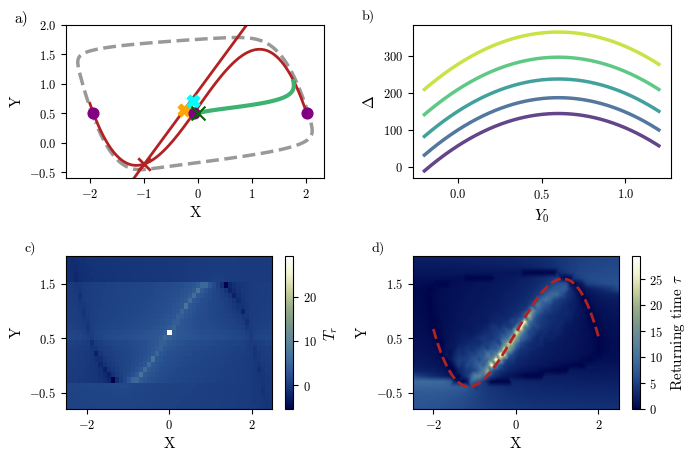

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import ast

# ================================================
# 🧩 Helper function: safely parse possible strings
# ================================================
def to_array(val):
    if isinstance(val, str):
        try:
            val = ast.literal_eval(val)
        except Exception:
            pass
    return np.array(val, dtype=float)

# ================================================
# 🎨 Define common colormap
# ================================================
try:
    cmap_common = dmftaffa.Davos_10.mpl_colormap  # if you have this custom palette
except Exception:
    cmap_common = 'viridis'  # fallback

# ================================================
# 🖼️ Create 4-panel figure
# ================================================
fig, axs = plt.subplots(2, 2, figsize=(18/2.54, 12/2.54))
ax_a, ax_b, ax_c, ax_d = axs.flat

# =========================================================
# (a) Limit cycle and interest points
# =========================================================
# =========================================================
# (a) Limit cycle and key points — improved visual version
# =========================================================
eps = 0.3
x0 = 0
y0 = 0.5

df_slice = df_cleaned[
    np.isclose(df_cleaned['epsilon'], eps)
    & np.isclose(df_cleaned['icx'], x0)
    & np.isclose(df_cleaned['icy'], y0)
]

row = df_slice.iloc[0]

lc_x = to_array(row['lc_x'])
lc_y = to_array(row['lc_y'])
baricenter = to_array(row['baricenter'])
geometric_center = to_array(row['geometric_center'])
unstable_points = to_array(row['unstable_points'])
Xs_return = to_array(row['Xs_return'])[:1, :100]
Ys_return = to_array(row['Ys_return'])[:1, :100]
X0 = row['icx']
Y0 = row['icy']
xs = to_array(row['xs'])
fs = to_array(row['fs'])
gs = to_array(row['gs'])

ax = ax_a

# ---- Main curves ----
ax.plot(lc_x, lc_y, '--', color='gray', lw=2.5, alpha=0.8, label='Limit cycle')
ax.plot(xs, fs, color='firebrick', lw=2, label=r'$y = f(x)$')
ax.plot(xs, gs, color='firebrick', lw=2, label=r'$y = g(x)$')

# ---- Key points ----
ax.scatter(baricenter[0], baricenter[1], marker='X', color='orange', s=80, zorder=5, label='Baricenter')
ax.scatter(geometric_center[0], geometric_center[1], marker='X', color='cyan', s=80, zorder=5, label='Geometric center')

if len(unstable_points) > 0:
    ax.scatter(
        [p[0] for p in unstable_points],
        [p[1] for p in unstable_points],
        color='firebrick', marker='x', s=80, lw=2,
        label='Unstable points', zorder=6
    )

# ---- Return trajectory ----
if Xs_return.ndim == 2:
    ax.plot(
        Xs_return[0, :],
        Ys_return[0, :],
        color='mediumseagreen',
        lw=3,
        linestyle='-',
        label='Return trajectory',
        zorder=4
    )

# ---- Control point ----
ax.scatter(X0, Y0, marker='x', color='darkgreen', edgecolor='white', s=100, zorder=8, label='Control point')

# ---- Axes styling ----
#ax.set_xlim(-2.5, 2)
ax.set_ylim(-0.6, 2)
ax.set_xlabel('X')
ax.set_ylabel('Y')

roots = cubic_roots(
    p=( (1 + eps) / (-1/3) ),
    q=( (-1 * Y0 + 0.6) / (-1/3) )
)

ax.scatter(
    [root.real for root in roots if abs(root.imag) < 1e-12],
    [Y0]*len(roots),
    color='purple', marker='o', s=60, label='Cubic roots', zorder=7
)
# ---- Add visual guides for reference ----
#ax.axhline(0, color='black', lw=0.8, alpha=0.5)
#ax.axvline(0, color='black', lw=0.8, alpha=0.5)

# ---- Title / annotation ----
ax.text(-0.2, 1.1, 'a)', transform=ax.transAxes, fontweight='bold', fontsize=11, va='top')

# ---- Legend ----
'''
ax.legend(
    loc='upper right',
    fontsize=8,
    frameon=False,
    handlelength=1.5,
    handletextpad=0.4
)
'''

# ---- Grid for context ----
#ax.grid(alpha=0.25, lw=0.5)

# =========================================================
# (b) Discriminant plot — improved styling
# =========================================================
xi = 1
eps_list = [0.1, 0.2, 0.3, 0.4, 0.5]
nu = -1
mu = 0.6
delta = -1/3

colors_b = plt.cm.viridis(np.linspace(0.1, 0.9, len(eps_list)))

for eps, c in zip(eps_list, colors_b):
    Y_0 = np.linspace(-0.2, 1.2, 400)
    a = (xi + eps)
    b = nu * Y_0 + mu
    p = a / delta
    q = b / delta
    disc = -4 * p**3 - 27 * q**2
    ax_b.plot(Y_0, disc, color=c, lw=2.5, alpha=0.85, label=fr'$\epsilon={eps:.1f}$')

ax_b.set_xlabel('$Y_0$')
ax_b.set_ylabel(r'$\Delta$')
ax_b.text(-0.2, 1.1, 'b)', transform=ax_b.transAxes, fontweight='bold', va='top')
#ax_b.grid(alpha=0.3)
#ax_b.legend(frameon=False, loc='upper right')

# =========================================================
# (c) Tau₁ heatmap — improved styling
# =========================================================
ax = ax_c

grid_tau1=np.real(pivot_tau1.values)
sc = ax.imshow(grid_tau1, extent=(x_low, x_high, y_low, y_high),
               origin='lower', cmap=cmap_common, aspect='auto')

# Overlay only fs nullcline with thicker lines and alpha
'''
for _, r in df_results.iterrows():
    try:
        xs = to_array(r['xs'])
        fs = to_array(r['fs'])
        if len(xs) == len(fs):
            ax.plot(xs, fs, color='firebrick', lw=1.2, alpha=0.5, zorder=5)
    except Exception:
        continue
'''
# Overlay only fs nullcline with thicker line
#ax.plot(x_f, fs, '--', color='firebrick', lw=1.0, zorder=0)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_xticks([-2, 0, 2])
ax.set_yticks([-0.5, 0.5, 1.5])
ax.text(-0.2, 1.1, 'c)', transform=ax.transAxes, fontweight='bold', va='top')
fig.colorbar(sc, ax=ax, label=r'$T_r$')

# =========================================================
# (d) Mean return time heatmap — improved styling
# =========================================================
ax = ax_d
sc2 = ax.imshow(grid_values, extent=(x_low, x_high, y_low, y_high),
                origin='lower', cmap=cmap_common, aspect='auto')

# Overlay only fs nullcline with thicker line
ax.plot(x_f, fs, '--', color='firebrick', lw=2.0, zorder=6)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_xticks([-2, 0, 2])
ax.set_yticks([-0.5, 0.5, 1.5])
ax.set_xlim(x_low, x_high)
ax.set_ylim(y_low, y_high)
ax.text(-0.2, 1.1, 'd)', transform=ax.transAxes, fontweight='bold', va='top')
fig.colorbar(sc2, ax=ax, label='Returning time $\\tau$')
ax.legend(frameon=False, loc='lower right')


plt.tight_layout()
plt.savefig('/data/zenari/FH/results/figure_final_FH.pdf', bbox_inches='tight', pad_inches=0.1, dpi=300)


\textbf{Figure X: Overview of system dynamics.} 
\textbf{(a) Limit cycle and key points:} Trajectory of the limit cycle (dashed gray) with the nullclines $y = f(x)$ and $y = g(x)$ shown in firebrick. Key points include the baricenter (orange X), geometric center (cyan X), unstable points (red X), the return trajectory from the initial condition $(X_0, Y_0)$ in green, and the control point (dark green).  
\textbf{(b) Discriminant plot:} The discriminant $\Delta$ of the cubic equation as a function of the initial condition $Y_0$ for different values of $\epsilon$ ($\epsilon = 0.1, 0.2, 0.3, 0.4, 0.5$), illustrating how the number and nature of roots change with $\epsilon$.  
\textbf{(c) Interpolated field of $\tau_1$:} Heatmap of the interpolated return time $\tau_1$ over the $(x, y)$ plane, with only the nullcline $y = f(x)$ overlaid in firebrick to show structure of the flow.  
\textbf{(d) Return time field for $\epsilon = 0.3$:} Heatmap of the mean return time $\tau$ for the selected $\epsilon$, with the nullcline $y = f(x)$ overlaid in firebrick to indicate the flow geometry.
